In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers, models, utils, datasets
import numpy as np
from sklearn.metrics import confusion_matrix

Text(0.5, 1.0, '2')

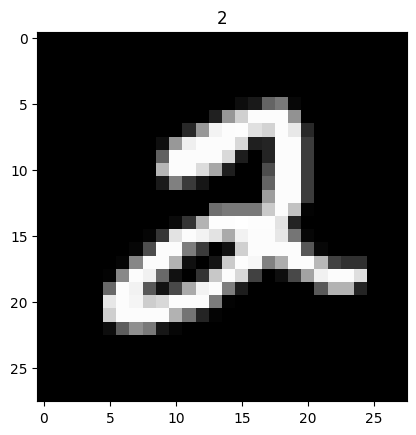

In [ ]:
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()
plt.imshow(X_train[5], cmap='gray')
plt.title(y_train[5])

In [ ]:
print(X_train.shape)

(60000, 28, 28)


In [ ]:
X_train = X_train.flatten().reshape(60000, 784).astype('float32')
X_test = X_test.flatten().reshape(10000, 784).astype('float32')

X_train /= 255
X_test /= 255

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [ ]:
# Reduzir dimensionalidade preservando 95% de sua variancia, para ocupar menos espaço. Cada instância terá pouco mais de 150 features, reduzindo 20% do tamanho
#from sklearn.decomposition import PCA
#pca = PCA(n_components = 300) #ou 0.95 (porém neste caso X_test fica com amostras a menos e dá erro)
#X_train_pca = pca.fit_transform(X_train)
#X_test_pca = pca.fit_transform(X_test)

In [ ]:
#transformando target em dummy (onehotencoder)
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

In [ ]:
y_train[5]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
from keras import regularizers

# dropout - técnica de regularização NN baseada em ensemble (p. 258-268 Livro Goodfellow)
def train_nn(hidden_layers, neurons, activation_function_hidden, drop_out, epochs):
    #https://www.tensorflow.org/guide/keras/sequential_model?hl=pt-br
    model = keras.Sequential()

    #primeira camada oculta + camada de entrada
    model.add(layers.Dense(units=neurons, activation=activation_function_hidden, input_dim=784))
    model.add(layers.Dropout(drop_out)) #regularização

    #camadas ocultas adicionais com dropout
    for n in range(hidden_layers):
        model.add(layers.Dense(units=neurons, activation=activation_function_hidden))
        model.add(layers.Dropout(drop_out))

    #camada de saída com 10 saídas -  multiclasse com função de ativação softmax (iremos ver em regressão logística)
    model.add(layers.Dense(units=10, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    """Use this crossentropy loss function when there are two or more label classes.
    We expect labels to be provided in a one_hot representation. If you want to provide labels as integers,
    please use SparseCategoricalCrossentropy loss. There should be num_classes floating point values per feature, i.e.,
    the shape of both y_pred and y_true are [batch_size, num_classes].
    """

    model.summary()

    histdata = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test))
    print(histdata.history.keys())

    # plot loss during training
    plt.subplot(211)
    plt.title('Loss')
    plt.plot(histdata.history['loss'], label='train')
    plt.plot(histdata.history['val_loss'], label='test')
    plt.legend()

    # plot precision during training
    plt.subplot(212)
    plt.title('Accuracy')
    plt.plot(histdata.history['accuracy'], label='train')
    plt.plot(histdata.history['val_accuracy'], label='test')
    plt.legend()
    plt.show()

    #loss = plt.plot(histdata.history['val_loss']) #diferenca entre predito e observado
    #pr = plt.plot(histdata.history['val_precision']) #diferença entre erros e acertos
    _, train_acc = model.evaluate(X_train, y_train, verbose=0)
    _, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))
    #plt.savefig('loss.png')
    plt.close()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,274 (51.85 KB)

 Trainable params: 13,274 (51.85 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7542 - loss: 0.7899 - val_accuracy: 0.9209 - val_loss: 0.2826
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9247 - loss: 0.2625 - val_accuracy: 0.9356 - val_loss: 0.2164
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9386 - loss: 0.2087 - val_accuracy: 0.9440 - val_loss: 0.1865
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9471 - loss: 0.1802 - val_accuracy: 0.9523 - val_loss: 0.1650
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9517 - loss: 0.1594 - val_accuracy: 0.9501 - val_loss: 0.1708
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9540 - loss: 0.1516 - val_accuracy: 0.9542 - val_loss: 0.1555
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9579 - loss: 0.1410 - val_accuracy: 0.9537 - val_loss: 0.1624
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9594 - loss: 0.1322 - 

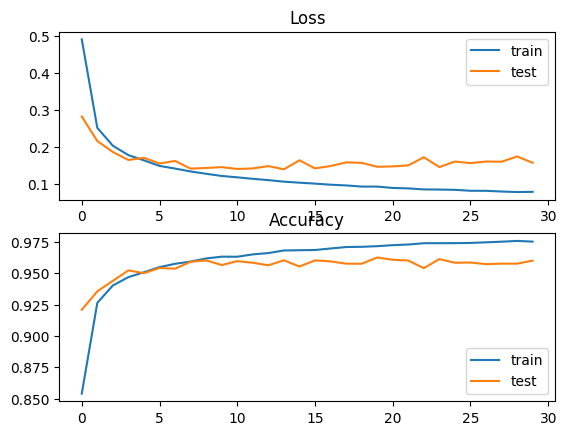

Train: 0.981, Test: 0.960


In [ ]:
train_nn(2, 16,'relu',0.0, 30)

#### [TAREFA] Pesquise como usar o OPTUNA com o KERAS, criando um experimento com as sugestões de modificação abaixo, mas sugere-se ver também sugestões no chatgpt das principais técnicas para reduzir overfitting

In [ ]:
"""
hidden_layers = [1, 2, 3]
neurons = [10,32,64]
activation = ['relu', 'tanh']
drop_out = [0.1, 0.2]
epochs = [5, 10, 20]

# 108 modelos

for layers in hidden_layers:
    for n in neurons:
        for act in activation:
            for drop in drop_out:
                for e in epochs:
                    train_nn(layers, n, act, drop, e)
"""

"\nhidden_layers = [1, 2, 3]\nneurons = [10,32,64]\nactivation = ['relu', 'tanh']\ndrop_out = [0.1, 0.2]\nepochs = [5, 10, 20]\n\n# 108 modelos\n\nfor layers in hidden_layers:\n    for n in neurons:\n        for act in activation:\n            for drop in drop_out:\n                for e in epochs:\n                    train_nn(layers, n, act, drop, e)\n"

In [ ]:
# 1. Instalação do Optuna no ambiente do Colab
!pip install optuna -q

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import optuna

# Verificar se o TensorFlow está utilizando a GPU
print("Dispositivos GPU detectados:", tf.config.list_physical_devices('GPU'))

# 2. Carregamento e Pré-processamento dos Dados (MNIST)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalização das imagens para o intervalo [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Redimensionar para incluir a dimensão de canal (28, 28, 1) se utilizar CNN ou Flatten
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 3. Definição da Função Objetivo para o Optuna
def objective(trial):
    # A) Espaço de busca de hiperparâmetros
    n_layers = trial.suggest_int("n_layers", 1, 3)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    drop_rate = trial.suggest_float("drop_rate", 0.1, 0.5)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    # B) Construção dinâmica da Arquitetura do Modelo
    model = keras.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))
    model.add(layers.Flatten())

    for i in range(n_layers):
        units = trial.suggest_int(f"units_l{i}", 32, 256, log=True)
        model.add(layers.Dense(units, activation="relu"))
        model.add(layers.Dropout(drop_rate))

    # Camada de Saída (10 classes para o MNIST)
    model.add(layers.Dense(10, activation="softmax"))

    # Compilação do Modelo
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # C) Treinamento do Modelo
    # O TensorFlow automaticamente transfere o treinamento para a GPU disponível
    history = model.fit(
        x_train,
        y_train,
        validation_split=0.1,
        epochs=5,
        batch_size=batch_size,
        verbose=0
    )

    # Retorna a acurácia de validação da última época como métrica a ser maximizada
    val_accuracy = history.history["val_accuracy"][-1]
    return val_accuracy


# 4. Execução do Estudo com Optuna
if __name__ == "__main__":
    # Criar estudo do Optuna focado em maximizar a acurácia de validação
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=15) # Altere n_trials conforme sua necessidade

    print("\n--- RESULTADOS DA OTIMIZAÇÃO ---")
    print(f"Melhor acurácia de validação: {study.best_value:.4f}")
    print("Melhores hiperparâmetros encontrados:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")